<a href="https://colab.research.google.com/github/LucasTonolli/projeto-ciencia-dados/blob/main/Projeto_Pr%C3%A9_processamento_de_Dados_em_Ci%C3%AAncia_de_Dad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importação de Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


#Análise inicial dos dados

## Leitura do dataset

In [4]:
df = pd.read_csv('sample_data/vgsales.csv',quotechar='"',
    encoding='utf-8',
    on_bad_lines='skip')

print("=== DATAFRAME ORIGINAL ===")
print(f'Dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas')
print(df)

=== DATAFRAME ORIGINAL ===
Dataset carregado: 16598 linhas e 11 colunas
        Rank              Name Platform    Year     Genre Publisher  NA_Sales  \
16597  16600  Spirits & Spells      GBA 2003.00  Platform   Wanadoo      0.01   

       EU_Sales  JP_Sales  Other_Sales  Global_Sales  
16597      0.00      0.00         0.00          0.01  


## Estrutura e tipos de variáveis

In [5]:
print("\n=== INFORMAÇÕES GERAIS DO DATAFRAME ===")
print(df.info())


=== INFORMAÇÕES GERAIS DO DATAFRAME ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB
None


## Verificação de dados ausentes

In [6]:
ausentes_nan = df.isnull().sum()

# Contagem de strings 'N/A' e 'Unknown' que o pandas não detecta automaticamente
ausentes_str = pd.Series({
    col: (df[col].astype(str).isin(['N/A', 'Unknown', 'nan'])).sum()
    for col in df.columns
})

df_ausentes = pd.DataFrame({
    'NaN (pandas)': ausentes_nan,
    'Strings inválidas (N/A / Unknown)': ausentes_str,
})
df_ausentes['Total ausentes'] = df_ausentes.sum(axis=1)
df_ausentes['% do total'] = (df_ausentes['Total ausentes'] / len(df) * 100).round(2)

print('=== VALORES AUSENTES POR COLUNA ===')
df_ausentes

=== VALORES AUSENTES POR COLUNA ===


,NaN (pandas),Strings inválidas (N/A / Unknown),Total ausentes,% do total
Rank,0,0,0,0.00
Name,0,0,0,0.00
Platform,0,0,0,0.00
Year,271,271,542,3.27
Genre,0,0,0,0.00
Publisher,58,261,319,1.92
NA_Sales,0,0,0,0.00
EU_Sales,0,0,0,0.00
JP_Sales,0,0,0,0.00
Other_Sales,0,0,0,0.00


## Inconsistência com o filtro declarado
> O dataset declara incluir apenas jogos acima de 100k cópias, porém 5.781 registros (34,83%) apresentam Global_Sales abaixo de 0.1 mi.

In [7]:
# Registros abaixo do threshold declarado de 100k cópias (0.1 mi)
abaixo_threshold = df[df['Global_Sales'] < 0.1]

print(f'Registros com Global_Sales < 0.1 mi (100k cópias): {len(abaixo_threshold)}')
print(f'% do total: {len(abaixo_threshold)/len(df)*100:.2f}%')
print()
print('Distribuição dos valores mais frequentes:')
print(abaixo_threshold['Global_Sales'].value_counts().head(10))

Registros com Global_Sales < 0.1 mi (100k cópias): 5781
% do total: 34.83%

Distribuição dos valores mais frequentes:
Global_Sales
0.02    1071
0.03     811
0.04     645
0.05     632
0.01     618
0.06     577
0.07     510
0.08     483
0.09     434
Name: count, dtype: int64


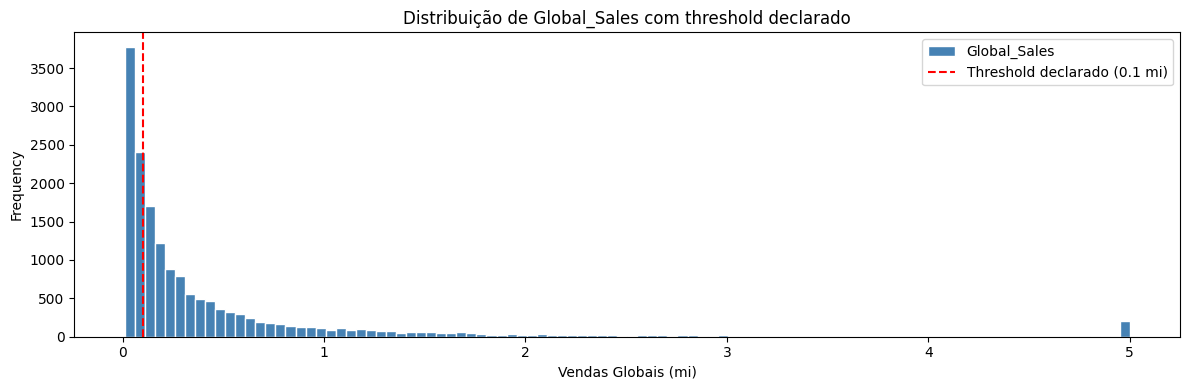

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
df['Global_Sales'].clip(upper=5).plot(kind='hist', bins=100, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(x=0.1, color='red', linestyle='--', label='Threshold declarado (0.1 mi)')
ax.set_title('Distribuição de Global_Sales com threshold declarado')
ax.set_xlabel('Vendas Globais (mi)')
ax.legend()
plt.tight_layout()
plt.show()

## Zeros nas vendas regionais

Os valores `0.00` presentes nas colunas de vendas regionais podem ter duas origens distintas:

1. **Valor real muito baixo** — o VGChartz registra vendas abaixo de 10.000 cópias (0.01 mi)
como `0.00` por arredondamento, ou seja, o jogo vendeu mas em quantidade desprezível.

2. **Dado ausente convertido** — conforme verificado diretamente no VGChartz, alguns jogos
apresentam `N/A` nas vendas regionais na fonte original. O script de scraping converte esses
valores para `np.nan`, porém o processamento aplicado antes da publicação no Kaggle substituiu
esses `NaN` por `0.00`, tornando impossível distingui-los dos zeros reais apenas com base no dataset.

Por essa razão, os zeros **não serão imputados** no pré-processamento.

In [9]:
print('=== ZEROS NAS VENDAS REGIONAIS ===')
colunas_vendas = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
for col in colunas_vendas:
    qtd = (df[col] == 0).sum()
    pct = qtd / len(df) * 100
    print(f'  {col}: {qtd} registros com zero ({pct:.2f}%)')

=== ZEROS NAS VENDAS REGIONAIS ===
  NA_Sales: 4499 registros com zero (27.11%)
  EU_Sales: 5730 registros com zero (34.52%)
  JP_Sales: 10455 registros com zero (62.99%)
  Other_Sales: 6477 registros com zero (39.02%)


## Outliers
> A análise de outliers nas vendas globais identificou o jogo Wii Sports como um caso extremo.
Com 82,74 milhões de cópias vendidas, representa quase o dobro do segundo colocado, sendo
consideravelmente distante do restante da distribuição.

> O contexto explica esse comportamento: o Wii Sports foi comercializado como bundle com o
console Wii na maioria dos mercados, ou seja, era incluído na caixa do console sem custo
adicional. Dessa forma, suas vendas refletem diretamente as vendas do hardware e não
representam uma venda independente do jogo em si, o que justifica sua remoção no pré-processamento.

> https://en.wikipedia.org/wiki/Wii_Sports


In [10]:
print('=== OUTLIER — WII SPORTS ===')
wii_sports = df[df['Name'] == 'Wii Sports']['Global_Sales'].values[0]
segundo = df[df['Name'] != 'Wii Sports']['Global_Sales'].max()
segundo_nome = df[df['Global_Sales'] == segundo]['Name'].values[0]

print(f'Wii Sports:         {wii_sports:.2f} mi')
print(f'Segundo colocado ({segundo_nome}): {segundo:.2f} mi')
print(f'Diferença:          {wii_sports - segundo:.2f} mi ({((wii_sports/segundo)-1)*100:.1f}% acima)')

=== OUTLIER — WII SPORTS ===
Wii Sports:         82.74 mi
Segundo colocado (Super Mario Bros.): 40.24 mi
Diferença:          42.50 mi (105.6% acima)


# Pré-processamento de dados


## Cópia de trabalho Criação

In [21]:
df_clean = df.copy()
print(f'Cópia de trabalho criada com sucesso.')
print(f'Shape: {df_clean.shape[0]} linhas e {df_clean.shape[1]} colunas')

Cópia de trabalho criada com sucesso.
Shape: 16597 linhas e 11 colunas


## Remover Wii Sports - motivo a ser estudado

> O Wii Sports é removido por ser um outlier extremo (82,74 mi de cópias) comercializado
como bundle com o console Wii, não representando uma venda independente. Sua presença
distorceria métricas como média e desvio padrão, além de comprometer a análise de
correlação por Publisher.



In [22]:
df_clean = df_clean[df_clean['Name'] != 'Wii Sports']
print(f'Wii Sports removido.')
print(f'Registros restantes: {len(df_clean)}')

Wii Sports removido.
Registros restantes: 16597


## Normalização de strings inválidas

> Os valores "N/A" e "Unknown" são convertidos para NaN real, padronizando a representação
de ausência de dados para tratamento uniforme nas etapas seguintes.

In [23]:
df_clean = df_clean.replace(['N/A', 'Unknown'], np.nan)

print('Strings inválidas convertidas para NaN.')
print()
print('Valores ausentes após normalização:')
print(df_clean.isnull().sum())

Strings inválidas convertidas para NaN.

Valores ausentes após normalização:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher       261
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


## Tratamento de Publisher ausente

> Os registros sem Publisher são removidos, pois a análise de correlação por Publisher é o
objetivo central do trabalho, tornando essas entradas inutilizáveis para a análise.

> A perda de 319 registros representa apenas 1,92% do total, sendo estatisticamente desprezível.

In [24]:
antes = len(df_clean)
df_clean = df_clean.dropna(subset=['Publisher'])
depois = len(df_clean)

print(f'Registros removidos por Publisher ausente: {antes - depois}')
print(f'Registros restantes: {depois}')

Registros removidos por Publisher ausente: 261
Registros restantes: 16336


## Tratamento de Year ausente

> Os registros com Year ausente são imputados com a mediana por plataforma.

> Cada console possui uma janela de vida bem definida no mercado, tornando a mediana dos anos daquela plataforma uma estimativa significativamente mais precisa do que a mediana global do dataset.

In [28]:
antes = df_clean['Year'].isnull().sum()

df_clean['Year'] = df_clean.groupby('Platform')['Year'].transform(
    lambda x: x.fillna(x.median())
)

# Caso alguma plataforma tenha apenas valores ausentes, usa a mediana global
df_clean['Year'] = df_clean['Year'].fillna(df_clean['Year'].median())
df_clean['Year'] = df_clean['Year'].astype(int)

print(f'Registros imputados em Year: {antes}')
print(f'Year ausentes restantes: {df_clean["Year"].isnull().sum()}')

ausentes_nan = df_clean.isnull().sum()

# Contagem de strings 'N/A' e 'Unknown' que o pandas não detecta automaticamente
ausentes_str = pd.Series({
    col: (df_clean[col].astype(str).isin(['N/A', 'Unknown', 'nan'])).sum()
    for col in df_clean.columns
})

df_ausentes = pd.DataFrame({
    'NaN (pandas)': ausentes_nan,
    'Strings inválidas (N/A / Unknown)': ausentes_str,
})
df_ausentes['Total ausentes'] = df_ausentes.sum(axis=1)
df_ausentes['% do total'] = (df_ausentes['Total ausentes'] / len(df) * 100).round(2)

print('=== VALORES AUSENTES POR COLUNA ===')
df_ausentes

Registros imputados em Year: 0
Year ausentes restantes: 0
=== VALORES AUSENTES POR COLUNA ===


,NaN (pandas),Strings inválidas (N/A / Unknown),Total ausentes,% do total
Rank,0,0,0,0.00
Name,0,0,0,0.00
Platform,0,0,0,0.00
Year,0,0,0,0.00
Genre,0,0,0,0.00
Publisher,0,0,0,0.00
NA_Sales,0,0,0,0.00
EU_Sales,0,0,0,0.00
JP_Sales,0,0,0,0.00
Other_Sales,0,0,0,0.00
